# Portfolio Performance Analysis

**Docker image**: `ml4t`

`ml4t-diagnostic` computes the risk-return metrics, drawdown episodes and
benchmark-relative statistics a portfolio report is built from, and replaces the
unmaintained pyfolio. The strategy
under analysis is the highest-validation-Sharpe ETF allocation backtest as recorded in
`case_studies/etfs/run_log/registry.db` - resolved at runtime via
`resolve_best_backtest_runs(...)` so the metrics always reflect the current
best-Sharpe allocator on validation, not a baked-in hash. Daily portfolio
returns are loaded from the case study's run-log, so every metric below traces
to a registered, cost-aware engine backtest on real ETF data. The validation
ranking chooses the artifact; the displayed return series is a strategy diagnostic,
not a fresh unbiased model-selection estimate.

**Learning Objectives**:
- Compute summary statistics (Sharpe, Sortino, Calmar, max drawdown)
- Analyze rolling performance metrics over configurable windows
- Create drawdown analysis with recovery period tracking
- Compare strategy performance against benchmarks (alpha, beta, IR)
- Perform event analysis during market stress periods

**Book Reference**: Chapter 17, Section 17.3 (Portfolio evaluation metrics)

**Prerequisites**: The ETF case study (`case_studies/etfs/`) must have been run
to produce `run_log/backtest/<hash>/daily_returns.parquet`.

In [1]:
"""Compute risk-return metrics, drawdowns, and stress-period analysis for ETF portfolios."""

import hashlib
import json

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl

# ml4t-diagnostic imports
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.evaluation.portfolio_analysis import (
    alpha_beta,
    annual_return,
    annual_volatility,
    calmar_ratio,
    conditional_var,
    information_ratio,
    max_drawdown,
    omega_ratio,
    stability_of_timeseries,
    value_at_risk,
)
from ml4t.diagnostic.metrics import sharpe_ratio, sortino_ratio
from ml4t.diagnostic.visualization import (
    combine_figures_to_html,
    create_portfolio_dashboard,
)

from case_studies.utils.registry.queries import resolve_best_backtest_runs
from data import load_etfs
from utils.paths import get_case_study_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_plotly_with_alt

Five settings decide what is analysed. `BACKTEST_HASH` left unset means the notebook picks the
strategy from the case study's registry rather than naming one: it takes the allocation-stage
backtest with the highest validation Sharpe on the 21-session forward-return target, so the
analysis follows whatever that case study currently produces instead of a hash that goes stale
the next time it is rebuilt. Setting it to a twelve-character hash pins one instead.

`BENCHMARK_SYMBOL` is what alpha, beta and the capture ratios are measured against, and it has
to be something the strategy could plausibly have been held instead of - SPY, a broad US equity
fund, for a strategy allocating across US-listed ETFs. `ETF_LABEL` names the target the
case study's models predicted, which is what makes the registry lookup unambiguous when a case
study fits more than one.

In [2]:
BACKTEST_HASH = None
BENCHMARK_SYMBOL = "SPY"
ETF_CASE_STUDY = "etfs"
ETF_LABEL = "fwd_ret_21d"
SEED = 42

In [3]:
set_global_seeds(SEED)

OUTPUT_DIR = get_output_dir(17, "portfolio_metrics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Strategy and Benchmark Returns

We load the daily portfolio return series from a registered ETF case-study
allocation backtest and use SPY as the benchmark. Rather than hard-code a
`prediction_hash` or `backtest_hash`, the notebook queries
`registry.db` via `resolve_best_backtest_runs()` and selects the allocation-stage
run with the highest validation Sharpe. The strategy is therefore whatever
the current case-study pipeline ranks first among ETF allocators on real OOS
data; see `case_studies/etfs/run_log/backtest/<hash>/spec.json` for its full
specification. The backtest artifact already includes its registered commission,
slippage, and next-bar execution assumptions; this notebook does not subtract costs again.

In [4]:
# Record the immutable registry before selecting its registered artifact.
registry_path = get_case_study_dir(ETF_CASE_STUDY) / "run_log" / "registry.db"
registry_sha256 = hashlib.sha256(registry_path.read_bytes()).hexdigest()
print(f"ETF registry SHA-256: {registry_sha256}")

# Resolve the backtest hash from the registry unless one was injected by Papermill.
if BACKTEST_HASH is None:
    best_runs = resolve_best_backtest_runs(
        case_study=ETF_CASE_STUDY,
        label=ETF_LABEL,
        split="validation",
        stage="allocation",
        top_n=1,
    )
    if best_runs.is_empty():
        raise RuntimeError(
            f"No allocation-stage backtests found for {ETF_CASE_STUDY}/{ETF_LABEL} on "
            "validation. Run the ETF case study (Ch16/17 stages) before this notebook."
        )
    best_row = best_runs.row(0, named=True)
    BACKTEST_HASH = best_row["backtest_hash"]
    backtest_spec = json.loads(best_row["spec_json"])
    execution = backtest_spec["backtest_config"]["execution"]
    commission = backtest_spec["backtest_config"]["commission"]
    slippage = backtest_spec["backtest_config"]["slippage"]
    allocator = backtest_spec["strategy"]["allocation"]
    if execution["execution_mode"] != "next_bar":
        raise RuntimeError("Selected backtest is not a causal next-bar execution artifact")
    print(
        f"Resolved highest-validation-Sharpe allocation backtest: {BACKTEST_HASH} "
        f"(prediction={best_row['prediction_hash']}, Sharpe={best_row['sharpe']:.3f})"
    )
    print(
        f"Registered assumptions: allocator={allocator['method']}, top_k={allocator['top_k']}, "
        f"execution={execution['execution_mode']}/{execution['execution_price']}, "
        f"commission={commission['model']}, slippage={slippage['model']}"
    )
else:
    print(f"Using user-pinned BACKTEST_HASH={BACKTEST_HASH}")

ETF registry SHA-256: a9c522b237730fca75dce9027fac0b033c35adb3d854ef46c98a65744a3d603b
Resolved highest-validation-Sharpe allocation backtest: 7d9832668c30 (prediction=a2883f9c5f84, Sharpe=0.837)
Registered assumptions: allocator=conformal_weighted, top_k=5, execution=next_bar/open, commission=per_share, slippage=spread


In [5]:
# Load strategy daily returns from the registered backtest
backtest_dir = get_case_study_dir(ETF_CASE_STUDY) / "run_log" / "backtest" / BACKTEST_HASH
returns_path = backtest_dir / "daily_returns.parquet"
if not returns_path.exists():
    raise FileNotFoundError(
        f"Backtest daily returns not found at {returns_path}. Re-run the ETF case "
        "study (see case_studies/etfs/) before this notebook."
    )

strategy_df = (
    pl.read_parquet(returns_path)
    .rename({"daily_return": "strategy"})
    .with_columns(pl.col("timestamp").cast(pl.Date))
    .sort("timestamp")
)
# Trim the leading pre-trade window where daily_return == 0 (before the first rebalance)
first_active = strategy_df.filter(pl.col("strategy") != 0)["timestamp"].min()
if first_active is None:
    raise RuntimeError(f"Registered backtest {BACKTEST_HASH} contains no active strategy returns")
strategy_df = strategy_df.filter(pl.col("timestamp") >= first_active)

strategy_returns = strategy_df.to_pandas().set_index("timestamp")["strategy"].astype(float)
strategy_returns.index = pd.to_datetime(strategy_returns.index)

In [6]:
# Load SPY benchmark over the same window
spy_lo, spy_hi = strategy_returns.index.min(), strategy_returns.index.max()
spy_data = (
    load_etfs()
    .filter(
        (pl.col("symbol") == BENCHMARK_SYMBOL)
        & (pl.col("timestamp") >= pl.lit(str(spy_lo.date())).str.to_datetime())
        & (pl.col("timestamp") <= pl.lit(str(spy_hi.date())).str.to_datetime())
    )
    .sort("timestamp")
)
spy_prices = spy_data.select(["timestamp", "close"]).to_pandas().set_index("timestamp")["close"]
spy_returns = spy_prices.pct_change().dropna()

# Align both series on the intersection of dates
common = strategy_returns.index.intersection(spy_returns.index)
strategy_returns = strategy_returns.loc[common].rename("Strategy")
spy_returns = spy_returns.loc[common]

print(
    f"Strategy: {len(strategy_returns):,} days  ({strategy_returns.index[0].date()} → {strategy_returns.index[-1].date()})"
)
print(f"Benchmark: {BENCHMARK_SYMBOL}, {len(spy_returns):,} days")

Strategy: 1,971 days  (2016-02-02 → 2023-11-29)
Benchmark: SPY, 1,971 days


## 2. Setting up the analysis

Every metric below is computed from the same three inputs - the strategy's daily returns, the
benchmark's, and the dates they fall on - so they are bound once here rather than passed
separately to each function. Two of the arguments are choices rather than data.

The **risk-free rate** is what gets subtracted before a ratio is taken. It is set to zero here,
which makes every Sharpe and Sortino below an excess-return-over-cash figure only to the extent
that cash paid nothing; over a window covering 2022-23 it did not, so these ratios are
marginally flattering. Applying the same rate to the benchmark does **not** leave the comparison
unchanged. Sharpe is $(\mu - r_f)/\sigma$, so raising the rate by $\Delta$ costs each series
$\Delta/\sigma$ - and that is *larger* for the series with the smaller volatility. The steadier
of the two loses more of its ratio, which is what can reorder them: a low-volatility series
ranked first at $r_f = 0$ can fall behind a more volatile one once a realistic cash rate is
subtracted from both. Sortino is not invariant either, and it is not a plain division:
`periodic_sortino_ratio` measures downside deviation on returns *after* subtracting the rate, so
raising the rate shrinks the numerator and grows the denominator at the same time. It still only
ever moves the ratio down - that holds for a strategy earning less than cash too, where the
numerator is negative and both effects might have been expected to fight - but by an amount that
is not $\Delta$ over anything, so read the two ratios' sensitivities as different in kind rather
than assuming Sharpe's arithmetic carries over. What a common rate does leave alone is the
information ratio, which is computed on
active returns - the difference between the two series, from which any rate applied to both
cancels before the ratio is taken.

**Periods per year** is what an annualization multiplies by. Daily equity returns are quoted
against 252 trading sessions. Switching to 365 does not move every annualized number by the same
amount, because two different scalings are at work: volatility and the ratios built on it scale
with the square root of the count, so they rise by sqrt(365/252), about 20%, while a compounded
annual return raises one plus the periodic return to the count itself and therefore moves with
the underlying growth rate rather than by a fixed factor.

In [7]:
# Create analysis object
analysis = PortfolioAnalysis(
    returns=strategy_returns.values,
    benchmark=spy_returns.values,
    dates=strategy_returns.index,
    risk_free=0.0,  # Can specify annual risk-free rate
    periods_per_year=252,
)

print(f"  Returns: {len(strategy_returns)} observations")
print("  Benchmark: SPY")
print("  Risk-free rate: 0%")

  Returns: 1971 observations
  Benchmark: SPY
  Risk-free rate: 0%


## 3. Summary Statistics

The headline table is the smallest set that does not mislead: a return, the volatility it was
earned at, two ratios of one against the other, the worst loss along the way, and three
benchmark-relative figures. Reporting the return alone says nothing about what was risked to
get it; reporting the Sharpe ratio alone hides how far the path fell before recovering.

In [8]:
# Compute all metrics.
metrics = analysis.compute_summary_stats()

headline_metrics = pd.DataFrame(
    {
        "Total Return": [f"{metrics.total_return:.2%}"],
        "Annual Return": [f"{metrics.annual_return:.2%}"],
        "Annual Volatility": [f"{metrics.annual_volatility:.2%}"],
        "Sharpe": [f"{metrics.sharpe_ratio:.3f}"],
        "Sortino": [f"{metrics.sortino_ratio:.3f}"],
        "Max Drawdown": [f"{metrics.max_drawdown:.2%}"],
        "Alpha": [f"{metrics.alpha:.2%}" if metrics.alpha is not None else "N/A"],
        "Beta": [f"{metrics.beta:.3f}" if metrics.beta is not None else "N/A"],
        "Information Ratio": [
            f"{metrics.information_ratio:.3f}" if metrics.information_ratio is not None else "N/A"
        ],
    },
    index=[BACKTEST_HASH],
)
headline_metrics

,Total Return,Annual Return,Annual Volatility,Sharpe,Sortino,Max Drawdown,Alpha,Beta,Information Ratio
7d9832668c30,198.43%,15.00%,18.78%,0.839,1.193,-24.42%,6.60%,0.637,0.086


### What each metric is sensitive to

The nine above answer different questions, and each is blind to something the next one sees.
What separates them is the denominator: what each one divides return by decides which kind of
bad outcome it can register at all.

| Metric | What it divides return by | What it cannot see |
|--------|---------------------------|--------------------|
| **Sharpe ratio** | total volatility | which side the volatility came from - an upside surprise penalises it as much as a loss |
| **Sortino ratio** | volatility of losses only | how long a loss lasted, or how deep the path went |
| **Calmar ratio** | the largest peak-to-trough loss | everything except that one episode |
| **Omega ratio** | the probability-weighted mass of losses | nothing about ordering: the same returns shuffled give the same number |
| **Tail ratio** | the size of the worst losses against the largest gains | the middle of the distribution, which is most of it |
| **Alpha** | nothing - it is a return, net of what the benchmark's moves explain | whether the deviations that produced it were large or small |
| **Information ratio** | the volatility of the deviations from the benchmark | the direction of the market the deviations were taken in |
| **Up capture** | the benchmark's return in its rising periods | anything about falling ones |
| **Down capture** | the benchmark's return in its falling periods | anything about rising ones |

There is no threshold that makes one of these good. A Sharpe of 1 is unremarkable for a
strategy trading at daily frequency and hard to reach for one holding positions for a quarter,
and the same number computed over three years and over thirty means different things because
the estimate's own standard error shrinks with the square root of the sample. What the table is
for is reading them together: a strategy that scores well on all of them is doing something
different from one that scores well on Sharpe alone.

## 4. Rolling Metrics

A single Sharpe ratio over the whole backtest is an average over every market the strategy
traded through. Recomputing it inside a moving window shows whether that average describes a
steady process or two different regimes with a crossover in the middle - which is the question
an investor with a finite horizon is actually asking.

Three windows are used, and the choice is a trade-off between resolution and noise. Twenty-one
sessions is about a calendar month: it responds within weeks and its Sharpe estimate swings
wildly, because a ratio estimated from twenty-one observations has a standard error close to
the ratio itself. Sixty-three sessions is a quarter. Two hundred and fifty-two is a year, which
smooths through most single episodes and therefore reacts to a regime change several months
after it happens. Reading the three together is what separates a change in the strategy from a
short run of luck.

In [9]:
# Compute rolling metrics
rolling = analysis.compute_rolling_metrics(
    windows=[21, 63, 252],  # 1-month, 3-month, 1-year
    metrics=["sharpe", "volatility", "returns"],
)

print("Rolling metrics computed:")
print(f"  windows: {rolling.windows}")
print(f"  sharpe: {list(rolling.sharpe.keys())}")
print(f"  volatility: {list(rolling.volatility.keys())}")
print(f"  returns: {list(rolling.returns.keys())}")

Rolling metrics computed:
  windows: [21, 63, 252]
  sharpe: [21, 63, 252]
  volatility: [21, 63, 252]
  returns: [21, 63, 252]


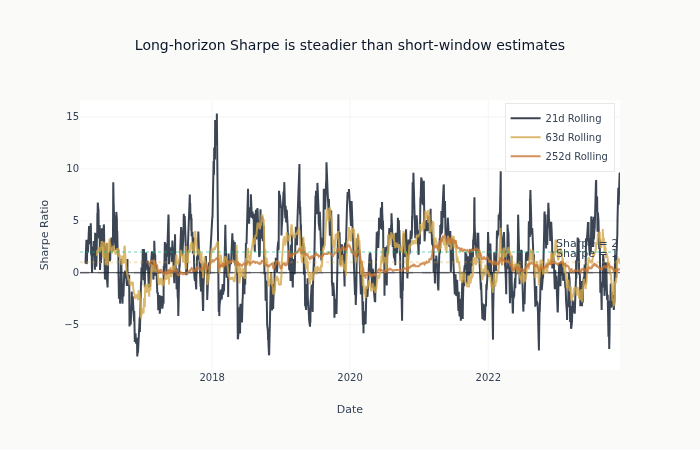

In [10]:
# Plot rolling Sharpe ratio
fig = go.Figure()

for window in [21, 63, 252]:
    if window in rolling.sharpe:
        sharpe_series = rolling.sharpe[window]
        fig.add_trace(
            go.Scatter(
                x=strategy_returns.index,
                y=sharpe_series.to_numpy(),
                name=f"{window}d Rolling",
                opacity=0.8,
            )
        )

fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], opacity=0.3)
fig.add_hline(
    y=1, line_dash="dot", line_color=COLORS["amber"], opacity=0.3, annotation_text="Sharpe = 1"
)
fig.add_hline(
    y=2, line_dash="dot", line_color=COLORS["positive"], opacity=0.3, annotation_text="Sharpe = 2"
)

fig.update_layout(
    title="Long-horizon Sharpe is steadier than short-window estimates",
    xaxis_title="Date",
    yaxis_title="Sharpe Ratio",
    height=450,
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99),
)
show_plotly_with_alt(
    fig,
    "Three lines of rolling Sharpe ratio against date, over 21, 63 and 252 sessions. The 21-session line swings across the whole vertical range while the 252-session line stays within a narrow band.",
)

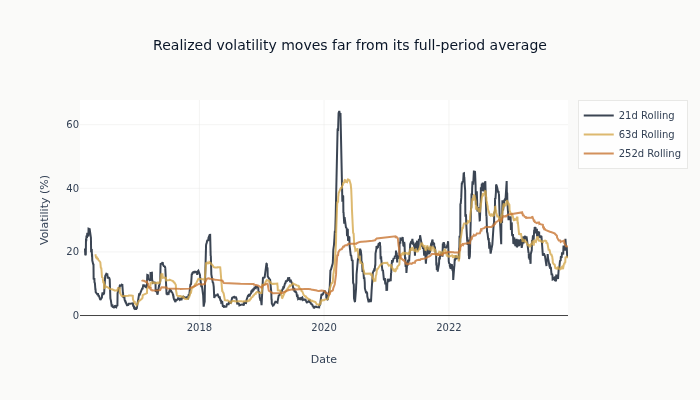

In [11]:
# Plot rolling volatility (annualized)
fig = go.Figure()

for window in [21, 63, 252]:
    if window in rolling.volatility:
        vol_series = rolling.volatility[window]
        fig.add_trace(
            go.Scatter(
                x=strategy_returns.index,
                y=vol_series.to_numpy() * 100,
                name=f"{window}d Rolling",
                opacity=0.8,
            )
        )

fig.update_layout(
    title="Realized volatility moves far from its full-period average",
    xaxis_title="Date",
    yaxis_title="Volatility (%)",
    height=400,
)
show_plotly_with_alt(
    fig,
    "Three lines of annualized rolling volatility against date, over 21, 63 and 252 sessions, with the shortest window spiking far above the other two during market stress.",
)

## 5. Drawdown Analysis

A **drawdown** is the loss from a peak in cumulative value to the lowest point before that peak
is regained, measured as a fraction of the peak. It is the loss an investor who bought at the
worst moment actually lived through, which is why it drives the decision to abandon a strategy
in a way that volatility does not: volatility is symmetric and a drawdown is not.

Three numbers describe one: how deep it went, how long it took to reach the bottom, and how
long it took to climb back to the old peak. The last of the three is the one usually left out,
and it is the one that decides whether a strategy is holdable - the same loss recovered in two
months and recovered in four years is the same number and not the same experience. Both
durations below are counted in trading sessions, not calendar days, because that is the grid
the return series is quoted on.

In [12]:
# Compute drawdown analysis
drawdown = analysis.compute_drawdown_analysis(top_n=5)

print("The five deepest drawdowns:")
for i, dd in enumerate(drawdown.top_drawdowns, 1):
    print(f"\n  #{i}: {dd.depth * 100:.2f}%")
    print(f"      Peak:            {dd.peak_date.date()}")
    print(f"      Valley:          {dd.valley_date.date()}")
    print(f"      Recovered:       {dd.recovery_date.date() if dd.recovery_date else 'not yet'}")
    print(f"      Peak to valley:  {dd.duration_days} sessions")
    recovery = f"{dd.recovery_days} sessions" if dd.recovery_days is not None else "still under"
    print(f"      Valley to peak:  {recovery}")

The five deepest drawdowns:

  #1: -24.42%
      Peak:            2020-02-12
      Valley:          2020-03-23
      Recovered:       2020-11-05
      Peak to valley:  27 sessions
      Valley to peak:  159 sessions

  #2: -21.96%
      Peak:            2022-11-30
      Valley:          2023-05-04
      Recovered:       not yet
      Peak to valley:  106 sessions
      Valley to peak:  still under

  #3: -18.80%
      Peak:            2022-08-12
      Valley:          2022-09-26
      Recovered:       2022-11-04
      Peak to valley:  30 sessions
      Valley to peak:  29 sessions

  #4: -15.51%
      Peak:            2022-03-08
      Valley:          2022-05-11
      Recovered:       2022-08-10
      Peak to valley:  45 sessions
      Valley to peak:  62 sessions

  #5: -11.20%
      Peak:            2021-07-01
      Valley:          2021-08-19
      Recovered:       2021-11-05
      Peak to valley:  34 sessions
      Valley to peak:  55 sessions


`compute_drawdown_analysis` above returns the episodes; the underwater curve below needs the
value on every date, which is the same quantity evaluated continuously. It is three lines -
compound the returns, carry the running maximum, take the shortfall from it - and it is written
out here rather than called because seeing the definition once is what makes the chart readable.

In [13]:
def compute_drawdown_series(returns: pd.Series) -> pd.Series:
    """Compute drawdown time series."""
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    return drawdown


dd_series = compute_drawdown_series(strategy_returns)
dd_benchmark = compute_drawdown_series(spy_returns)

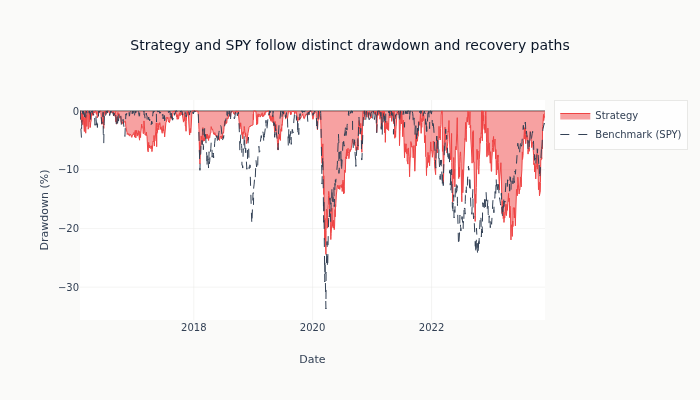

In [14]:
# Plot underwater curve
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=dd_series.index,
        y=dd_series * 100,
        name="Strategy",
        fill="tozeroy",
        line=dict(color=COLORS["negative"], width=1),
    )
)

fig.add_trace(
    go.Scatter(
        x=dd_benchmark.index,
        y=dd_benchmark * 100,
        name="Benchmark (SPY)",
        line=dict(color=COLORS["neutral"], width=1, dash="dash"),
    )
)

fig.update_layout(
    title="Strategy and SPY follow distinct drawdown and recovery paths",
    xaxis_title="Date",
    yaxis_title="Drawdown (%)",
    height=400,
)
show_plotly_with_alt(
    fig,
    "Two underwater curves against date, the strategy filled to zero and the benchmark dashed, each showing the percentage below its own running peak.",
)

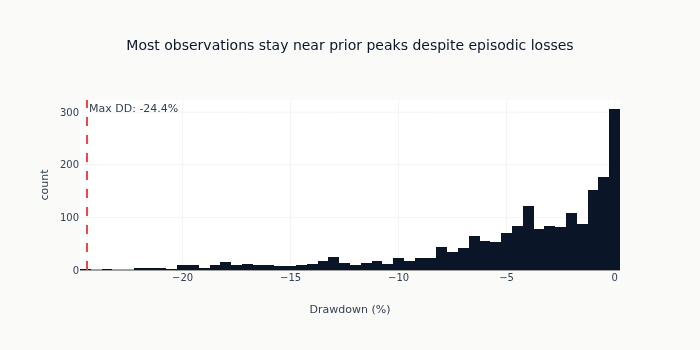

In [15]:
# Drawdown distribution
fig = px.histogram(
    dd_series * 100,
    nbins=50,
    title="Most observations stay near prior peaks despite episodic losses",
    labels={"value": "Drawdown (%)", "count": "Frequency"},
)
fig.add_vline(
    x=metrics.max_drawdown * 100,
    line_dash="dash",
    line_color=COLORS["negative"],
    annotation_text=f"Max DD: {metrics.max_drawdown * 100:.1f}%",
)
fig.update_layout(height=350, showlegend=False)
show_plotly_with_alt(
    fig,
    "Histogram of the strategy's daily drawdown, concentrated near zero with a thin tail reaching the maximum drawdown marked by a vertical line.",
)

## 6. Monthly and Annual Returns

Daily returns compounded to month and year ends answer a question the aggregate figures do
not: how much of the total came from how few periods. A strategy whose annual return is
carried by two months is a different proposition from one earning the same amount steadily,
and the two are indistinguishable in a Sharpe ratio computed over the whole sample.

In [16]:
# Compute monthly returns
monthly = analysis.compute_monthly_returns()
monthly_df = monthly.to_pandas()  # Convert Polars to pandas

print("Monthly Return Statistics:")
print(f"  Mean:   {monthly_df['monthly_return'].mean() * 100:.2f}%")
print(f"  Std:    {monthly_df['monthly_return'].std() * 100:.2f}%")
print(f"  Best:   {monthly_df['monthly_return'].max() * 100:.2f}%")
print(f"  Worst:  {monthly_df['monthly_return'].min() * 100:.2f}%")

Monthly Return Statistics:
  Mean:   1.28%
  Std:    4.88%
  Best:   16.26%
  Worst:  -11.37%


The heatmap below is the same monthly series as a year-by-month grid. Read down a column to see
whether a calendar month is systematically good or bad, and across a row to see how much of a
year's return came from how few of its months.

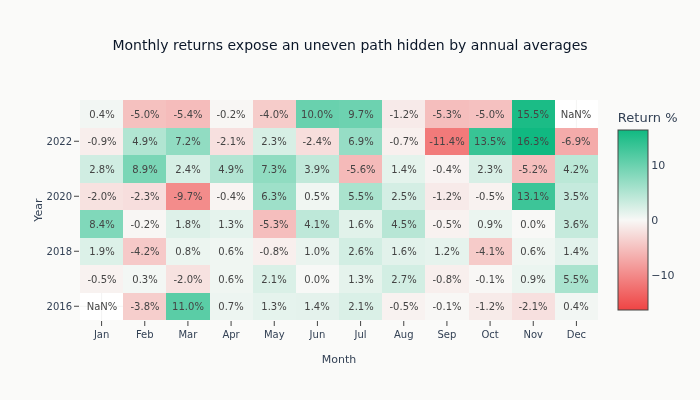

In [17]:
monthly_df["year"] = monthly_df["year"].astype(int)
monthly_df["month"] = monthly_df["month"].astype(int)

heatmap_data = (
    monthly_df.pivot(index="year", columns="month", values="monthly_return") * 100
)  # Convert to percentage

# Month names
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig = go.Figure(
    data=go.Heatmap(
        z=heatmap_data.values,
        x=month_names,
        y=heatmap_data.index,
        colorscale=[
            [0.0, COLORS["negative"]],
            [0.5, COLORS["silver"]],
            [1.0, COLORS["positive"]],
        ],
        zmid=0,
        text=np.round(heatmap_data.values, 1),
        texttemplate="%{text:.1f}%",
        textfont={"size": 10},
        colorbar=dict(title="Return %"),
    )
)

fig.update_layout(
    title="Monthly returns expose an uneven path hidden by annual averages",
    xaxis_title="Month",
    yaxis_title="Year",
    height=400,
)
show_plotly_with_alt(
    fig,
    "Heatmap of monthly returns, years down the vertical axis and calendar months across, red for losses and green for gains, with each cell labelled.",
)

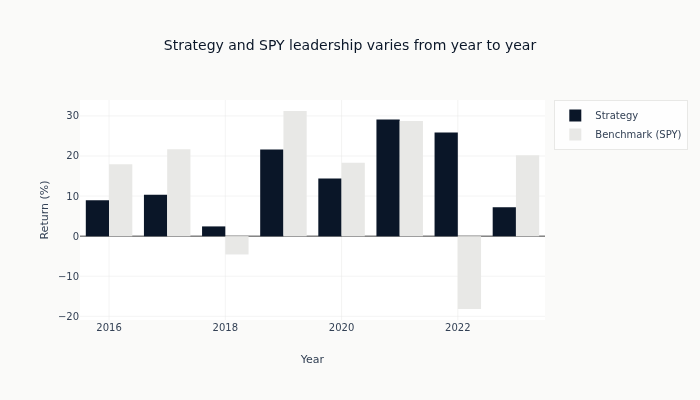

In [18]:
# Annual returns comparison
annual = analysis.compute_annual_returns()
annual_df = annual.to_pandas()  # Convert Polars to pandas

# Also compute benchmark annual
spy_annual = spy_returns.groupby(spy_returns.index.year).apply(lambda x: (1 + x).prod() - 1)

# Create comparison
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=annual_df["year"],
        y=annual_df["annual_return"] * 100,
        name="Strategy",
        marker_color=COLORS["blue"],
    )
)

fig.add_trace(
    go.Bar(
        x=spy_annual.index,
        y=spy_annual.values * 100,
        name="Benchmark (SPY)",
        marker_color=COLORS["silver_muted"],
    )
)

fig.update_layout(
    title="Strategy and SPY leadership varies from year to year",
    xaxis_title="Year",
    yaxis_title="Return (%)",
    barmode="group",
    height=400,
)
show_plotly_with_alt(
    fig,
    "Grouped bars of annual return for the strategy and for SPY, one pair per calendar year.",
)

## 7. Benchmark-Relative Analysis

Regressing the strategy's daily returns on the benchmark's splits them in two. **Beta** is the
slope: how much the strategy moved, on average, for each unit the market moved. **Alpha** is
the intercept, annualized: the part of the return the market's moves do not explain.

Beta is what decides whether alpha is interesting. A strategy with a beta of 1 and no alpha has
reproduced the index; one with a beta of 0.5 and no alpha has reproduced half of it and kept
half the capital idle. The bands below - under 0.8, over 1.2 - are conventional labels for
"materially less exposed than the market" and "materially more", and there is nothing special
about the two cutoffs beyond marking a fifth of the market's own movement in each direction.

In [19]:
alpha, beta = alpha_beta(strategy_returns.values, spy_returns.values, periods_per_year=252)

print(f"Alpha: {alpha * 100:.2f}% (annualized)")
print(f"Beta:  {beta:.3f}")

# Interpretation
if beta < 0.8:
    beta_interp = "Defensive (low market exposure)"
elif beta > 1.2:
    beta_interp = "Aggressive (high market exposure)"
else:
    beta_interp = "Neutral (market-like exposure)"
print(f"       {beta_interp}")

Alpha: 6.60% (annualized)
Beta:  0.637
       Defensive (low market exposure)


**Tracking error** is the volatility of the difference between the two return series, and the
**information ratio** divides the average of that difference by it. Together they ask whether
the deviations from the benchmark were worth taking: a strategy can exceed its benchmark by a
wide margin through deviations so volatile that the excess is indistinguishable from luck.

Read the information ratio the way a t-statistic is read, because over $T$ years that is what
it is: multiplied by $\sqrt{T}$ it gives roughly the t-statistic of the average active return.
An information ratio of 0.5 sustained over four years is therefore about one standard error
from zero, which is why the number needs a horizon attached before it means anything.

In [20]:
active_returns = strategy_returns.values - spy_returns.values
tracking_error = active_returns.std(ddof=1) * np.sqrt(252)
ir = information_ratio(strategy_returns.values, spy_returns.values, periods_per_year=252)

years = len(strategy_returns) / 252
print(f"Tracking Error:    {tracking_error * 100:.2f}% (annualized)")
print(f"Information Ratio: {ir:.3f}  over {years:.1f} years")
print(f"Implied t-statistic on the average active return: {ir * np.sqrt(years):.2f}")

Tracking Error:    16.12% (annualized)
Information Ratio: 0.086  over 7.8 years
Implied t-statistic on the average active return: 0.24


**Capture ratios** split the comparison by the direction the benchmark moved. Up capture is
what the strategy returned across the periods the benchmark rose, as a fraction of what the
benchmark returned over those same periods; down capture is the same across the periods it
fell. A strategy capturing 80% of the upside and 50% of the downside is doing something a
single alpha number cannot express.

They are conventionally quoted on monthly periods rather than daily ones, so both series are
compounded to month ends before the ratio is taken. The frequency is part of the definition:
the same strategy scores differently at daily and monthly frequency, because a month in which
the benchmark ends up while falling for three weeks counts as an up period at one and as a mix
at the other.

The ratio is taken between the two *average* returns over those periods. `ml4t.diagnostic`
exposes an `up_down_capture` that instead divides the two compounded wealth factors, and for
down periods that inverts the reading: a strategy losing 5% in each month the benchmark loses
10% has captured half the downside, and the compounded form reports 111%, because both products
are below one and the larger numerator makes the ratio exceed it. Down capture above 100% is
supposed to mean the strategy fell harder than the market. Take the ratio of the means.

In [21]:
strat_monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
bench_monthly = spy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
up_months, down_months = bench_monthly > 0, bench_monthly < 0
up_capture = strat_monthly[up_months].mean() / bench_monthly[up_months].mean()
down_capture = strat_monthly[down_months].mean() / bench_monthly[down_months].mean()

print("Capture ratios, on monthly periods:")
print(f"  Up Capture:   {up_capture * 100:.1f}%")
print(f"  Down Capture: {down_capture * 100:.1f}%")

# The gap between the two is the asymmetry: positive means the strategy kept more of the
# benchmark's up months than of its down months.
capture_spread = up_capture - down_capture
print(f"  Spread (up - down): {capture_spread * 100:.1f}pp")

Capture ratios, on monthly periods:
  Up Capture:   81.3%
  Down Capture: 55.0%
  Spread (up - down): 26.3pp


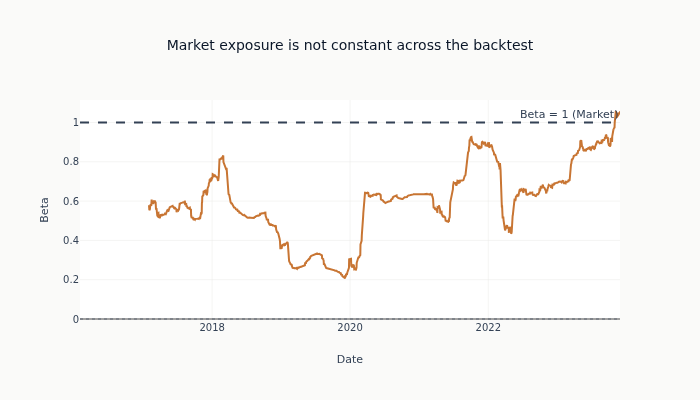

In [22]:
# Rolling Beta
rolling_beta = pd.Series(index=strategy_returns.index, dtype=float)

window = 252
for i in range(window, len(strategy_returns)):
    strat_window = strategy_returns.iloc[i - window : i].values
    bench_window = spy_returns.iloc[i - window : i].values
    _, beta_i = alpha_beta(strat_window, bench_window)
    rolling_beta.iloc[i] = beta_i

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=rolling_beta.index,
        y=rolling_beta,
        name="Rolling 1Y Beta",
        line=dict(color=COLORS["copper"], width=2),
    )
)

fig.add_hline(
    y=1, line_dash="dash", line_color=COLORS["neutral"], annotation_text="Beta = 1 (Market)"
)
fig.add_hline(y=0, line_dash="dot", line_color=COLORS["neutral"], opacity=0.3)

fig.update_layout(
    title="Market exposure is not constant across the backtest",
    xaxis_title="Date",
    yaxis_title="Beta",
    height=400,
)
show_plotly_with_alt(
    fig,
    "Rolling one-year beta against SPY plotted against date, with reference lines at one and zero.",
)

## 8. Risk Metrics (VaR, CVaR)

**Value at Risk** at a confidence level is the loss that a stated fraction of periods exceeded.
At 95% confidence on daily returns it is the daily loss that one day in twenty was worse than.
Both levels below are read as empirical quantiles of the return series itself: the returns are
sorted and the quantile is taken, with no distribution assumed.

In [23]:
# Value at Risk
var_95 = value_at_risk(strategy_returns.values, confidence=0.95)
var_99 = value_at_risk(strategy_returns.values, confidence=0.99)

print("Value at Risk, from the sample's own return distribution:")
print(f"  95% VaR: {var_95 * 100:.2f}% (daily)")
print(f"  99% VaR: {var_99 * 100:.2f}% (daily)")
print(
    f"  Read as: 5% of the {len(strategy_returns):,} days in this backtest lost more than "
    f"{abs(var_95) * 100:.2f}%."
)

Value at Risk, from the sample's own return distribution:
  95% VaR: -1.81% (daily)
  99% VaR: -3.69% (daily)
  Read as: 5% of the 1,971 days in this backtest lost more than 1.81%.


VaR says where the tail begins and nothing about what is inside it: a strategy losing 3% on its
worst day and one losing 30% can share a 95% VaR. **Conditional VaR**, also called expected
shortfall, is the average of the losses that did exceed the threshold, so it is the number that
separates them. It is the reason a risk report quotes both.

Both are read off this sample's own history. Neither is a forecast, and the estimate of a 99%
quantile from a few thousand observations rests on a few dozen of them.

In [24]:
cvar_95 = conditional_var(strategy_returns.values, confidence=0.95)
cvar_99 = conditional_var(strategy_returns.values, confidence=0.99)

print("Conditional VaR, the average loss on the days that breached VaR:")
print(f"  95% CVaR: {cvar_95 * 100:.2f}% (daily)")
print(f"  99% CVaR: {cvar_99 * 100:.2f}% (daily)")

Conditional VaR, the average loss on the days that breached VaR:
  95% CVaR: -2.96% (daily)
  99% CVaR: -4.81% (daily)


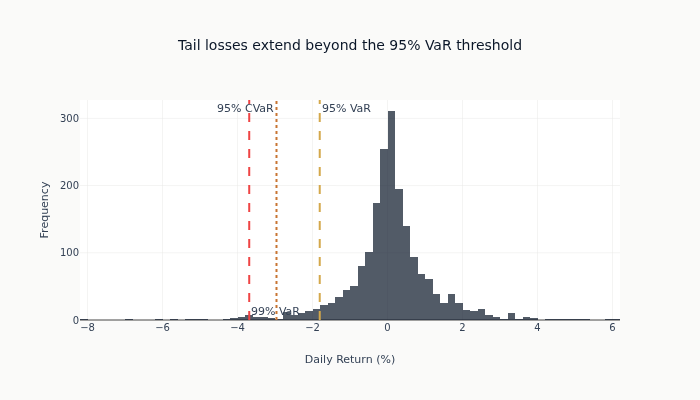

In [25]:
# Visualize return distribution with VaR
fig = go.Figure()

# Histogram of returns
fig.add_trace(go.Histogram(x=strategy_returns * 100, nbinsx=100, name="Daily Returns", opacity=0.7))

# VaR lines - stagger annotation y-positions to prevent overlap at the top
fig.add_vline(
    x=var_95 * 100,
    line_dash="dash",
    line_color=COLORS["amber"],
    annotation_text="95% VaR",
    annotation_position="top right",
)
fig.add_vline(
    x=var_99 * 100,
    line_dash="dash",
    line_color=COLORS["negative"],
    annotation_text="99% VaR",
    annotation_position="bottom right",
)
fig.add_vline(
    x=cvar_95 * 100,
    line_dash="dot",
    line_color=COLORS["copper"],
    annotation_text="95% CVaR",
    annotation_position="top left",
)

fig.update_layout(
    title="Tail losses extend beyond the 95% VaR threshold",
    xaxis_title="Daily Return (%)",
    yaxis_title="Frequency",
    height=400,
    showlegend=False,
)
show_plotly_with_alt(
    fig,
    "Histogram of daily strategy returns with vertical lines marking the 95% and 99% value at risk and the corresponding conditional value at risk further into the left tail.",
)

## 9. Event Analysis

Aggregate statistics average over every market the strategy traded through, so they say
nothing about the episodes an investor remembers. Cumulating the strategy and the benchmark
over five named windows - two crashes, two recoveries and one credit event - shows whether the
defensive profile the beta and capture ratios suggest actually held when it was tested.

The five windows are chosen after the fact, which is what makes this a description rather than
a test. Each is bounded by the dates the episode is conventionally dated to; the strategy's
behaviour outside them is what every other section measures.

In [26]:
# Define market stress periods
STRESS_PERIODS = {
    "COVID Crash (2020)": ("2020-02-19", "2020-03-23"),
    "COVID Recovery": ("2020-03-23", "2020-08-31"),
    "2022 Bear Market": ("2022-01-03", "2022-10-12"),
    "2023 Banking Crisis": ("2023-03-01", "2023-03-31"),
    "2023 Rally": ("2023-10-27", "2023-12-29"),
}


def analyze_period(returns: pd.Series, benchmark: pd.Series, start: str, end: str):
    """Analyze returns over a specific period."""
    period_ret = returns.loc[start:end]
    period_bench = benchmark.loc[start:end]

    if len(period_ret) == 0:
        return None

    cum_ret = (1 + period_ret).prod() - 1
    cum_bench = (1 + period_bench).prod() - 1
    excess = cum_ret - cum_bench

    return {
        "strategy_return": cum_ret,
        "benchmark_return": cum_bench,
        "excess_return": excess,
        "days": len(period_ret),
    }

In [27]:
period_results = []
for name, (start, end) in STRESS_PERIODS.items():
    result = analyze_period(strategy_returns, spy_returns, start, end)
    if result:
        result["period"] = name
        period_results.append(result)
        print(f"\n{name}:")
        print(f"  Strategy:  {result['strategy_return'] * 100:+.2f}%")
        print(f"  Benchmark: {result['benchmark_return'] * 100:+.2f}%")
        print(f"  Excess:    {result['excess_return'] * 100:+.2f}%")


COVID Crash (2020):
  Strategy:  -23.28%
  Benchmark: -33.40%
  Excess:    +10.12%

COVID Recovery:
  Strategy:  +23.45%
  Benchmark: +53.34%
  Excess:    -29.89%

2022 Bear Market:
  Strategy:  +9.81%
  Benchmark: -24.06%
  Excess:    +33.87%

2023 Banking Crisis:
  Strategy:  -5.41%
  Benchmark: +3.71%
  Excess:    -9.12%

2023 Rally:
  Strategy:  +16.62%
  Benchmark: +10.20%
  Excess:    +6.42%


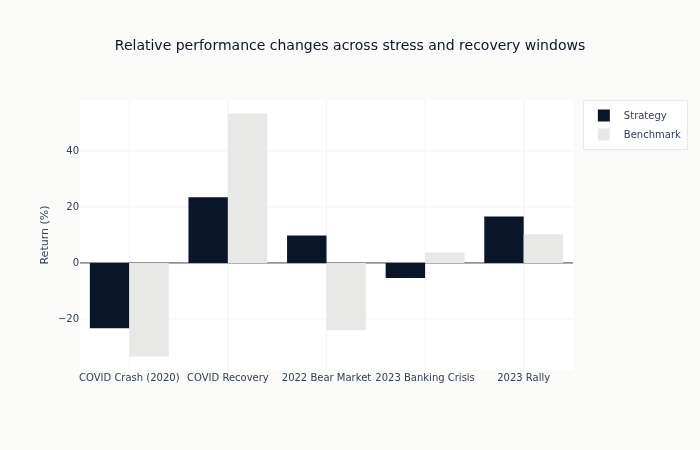

In [28]:
# Visualize stress period performance
if period_results:
    period_df = pd.DataFrame(period_results)

    fig = go.Figure()

    fig.add_trace(
        go.Bar(
            x=period_df["period"],
            y=period_df["strategy_return"] * 100,
            name="Strategy",
            marker_color=COLORS["blue"],
        )
    )

    fig.add_trace(
        go.Bar(
            x=period_df["period"],
            y=period_df["benchmark_return"] * 100,
            name="Benchmark",
            marker_color=COLORS["silver_muted"],
        )
    )

    fig.update_layout(
        title="Relative performance changes across stress and recovery windows",
        yaxis_title="Return (%)",
        barmode="group",
        height=450,
    )
    show_plotly_with_alt(
        fig,
        "Grouped bars of cumulative return for the strategy and the benchmark over five named stress and recovery windows.",
    )

## 10. Stability Analysis

**Stability** here is the R-squared of a straight line fitted to the cumulative value curve
against time. A value near one means the curve looks like a line, which is what a strategy
compounding at a steady rate produces; a lower value means the same total return arrived in
bursts. It is a description of the path, not of the return: a strategy that doubles in one
month and flatlines for four years scores badly and still doubled.

A high R-squared does not mean the path was comfortable. A straight line fitted to eight years
of compounding absorbs a drawdown lasting several months without much loss of fit, so read
this number against the drawdown table in section 5 rather than instead of it.

In [29]:
# Stability of returns (R² of cumulative returns vs time)
stability = stability_of_timeseries(strategy_returns.values)
print(f"Stability (R²): {stability:.3f}")

Stability (R²): 0.876


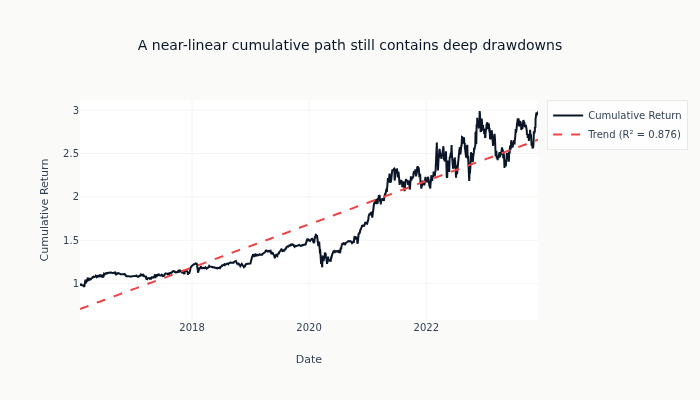

In [30]:
# Cumulative returns with trend line
cumulative = (1 + strategy_returns).cumprod()

# Fit trend line
x = np.arange(len(cumulative))
coeffs = np.polyfit(x, cumulative, 1)
trend = np.polyval(coeffs, x)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=cumulative.index,
        y=cumulative,
        name="Cumulative Return",
        line=dict(color=COLORS["blue"], width=2),
    )
)

fig.add_trace(
    go.Scatter(
        x=cumulative.index,
        y=trend,
        name=f"Trend (R² = {stability:.3f})",
        line=dict(color=COLORS["negative"], dash="dash"),
    )
)

fig.update_layout(
    title="A near-linear cumulative path still contains deep drawdowns",
    xaxis_title="Date",
    yaxis_title="Cumulative Return",
    height=400,
)
show_plotly_with_alt(
    fig,
    "Cumulative return against date with a fitted straight trend line overlaid, the two diverging where the path deviates from steady compounding.",
)

## 11. Full Performance Report

The sections above computed each family of statistics next to the reasoning that motivates it.
Collecting them into one table grouped by what they measure - return, risk, the ratio of one
to the other, and the comparison against the benchmark - is the form a report takes when it
goes to someone who did not follow the derivation.

In [31]:
# Build the summary table
summary_data = {"Category": [], "Metric": [], "Value": []}


def add_metric(category: str, name: str, value: str) -> None:
    summary_data["Category"].append(category)
    summary_data["Metric"].append(name)
    summary_data["Value"].append(value)

In [32]:
returns_metrics = [
    ("Total Return", f"{metrics.total_return * 100:.2f}%"),
    ("Annual Return (CAGR)", f"{metrics.annual_return * 100:.2f}%"),
    ("Best Month", f"{monthly_df['monthly_return'].max() * 100:.2f}%"),
    ("Worst Month", f"{monthly_df['monthly_return'].min() * 100:.2f}%"),
]
risk_metrics = [
    ("Annual Volatility", f"{metrics.annual_volatility * 100:.2f}%"),
    ("Max Drawdown", f"{metrics.max_drawdown * 100:.2f}%"),
    ("95% VaR (Daily)", f"{var_95 * 100:.2f}%"),
    ("95% CVaR (Daily)", f"{cvar_95 * 100:.2f}%"),
]
risk_adjusted_metrics = [
    ("Sharpe Ratio", f"{metrics.sharpe_ratio:.3f}"),
    ("Sortino Ratio", f"{metrics.sortino_ratio:.3f}"),
    ("Calmar Ratio", f"{metrics.calmar_ratio:.3f}"),
    ("Omega Ratio", f"{metrics.omega_ratio:.3f}"),
]
benchmark_metrics = []
if metrics.alpha is not None:
    benchmark_metrics = [
        ("Alpha", f"{metrics.alpha * 100:.2f}%"),
        ("Beta", f"{metrics.beta:.3f}"),
        ("Tracking Error", f"{tracking_error * 100:.2f}%"),
        ("Information Ratio", f"{metrics.information_ratio:.3f}"),
        ("Up Capture (monthly)", f"{up_capture * 100:.1f}%"),
        ("Down Capture (monthly)", f"{down_capture * 100:.1f}%"),
    ]
other_metrics = [
    ("Stability (R²)", f"{stability:.3f}"),
    ("Win Rate", f"{metrics.win_rate * 100:.1f}%"),
    ("Profit Factor", f"{metrics.profit_factor:.2f}"),
]

In [33]:
for name, value in returns_metrics:
    add_metric("Returns", name, value)
for name, value in risk_metrics:
    add_metric("Risk", name, value)
for name, value in risk_adjusted_metrics:
    add_metric("Risk-Adjusted", name, value)
for name, value in benchmark_metrics:
    add_metric("Benchmark", name, value)
for name, value in other_metrics:
    add_metric("Other", name, value)

In [34]:
summary_df = pd.DataFrame(summary_data)
summary_df

,Category,Metric,Value
0,Returns,Total Return,198.43%
1,Returns,Annual Return (CAGR),15.00%
2,Returns,Best Month,16.26%
3,Returns,Worst Month,-11.37%
4,Risk,Annual Volatility,18.78%
5,Risk,Max Drawdown,-24.42%
6,Risk,95% VaR (Daily),-1.81%
7,Risk,95% CVaR (Daily),-2.96%
8,Risk-Adjusted,Sharpe Ratio,0.839
9,Risk-Adjusted,Sortino Ratio,1.193


The four groups answer four questions and none of them answers another's. Read alpha together
with beta, tracking error and the information ratio: a positive alpha earned through deviations
whose own volatility swamps it has not established that the active positions were worth taking.
The two capture ratios then say where the residual profile came from - holding on in rising
markets, or losing less in falling ones.

## 12. The same metrics, one at a time

The class above computes everything from one binding. Each metric is also available as a plain
function over an array of returns, which is what to reach for when checking a single number
somewhere else without setting up an analysis object. The values below are the same ones the
table carries, computed the other way.

In [35]:
# Example: Computing metrics without PortfolioAnalysis class
returns_arr = strategy_returns.values
benchmark_arr = spy_returns.values

print("Standalone Metric Functions:")
print(f"  sharpe_ratio():       {sharpe_ratio(returns_arr):.3f}")
print(f"  sortino_ratio():      {sortino_ratio(returns_arr):.3f}")
print(f"  calmar_ratio():       {calmar_ratio(returns_arr):.3f}")
print(f"  omega_ratio():        {omega_ratio(returns_arr):.3f}")
print(f"  max_drawdown():       {max_drawdown(returns_arr) * 100:.2f}%")
print(f"  annual_return():      {annual_return(returns_arr) * 100:.2f}%")
print(f"  annual_volatility():  {annual_volatility(returns_arr) * 100:.2f}%")

Standalone Metric Functions:
  sharpe_ratio():       0.839
  sortino_ratio():      1.193
  calmar_ratio():       0.614
  omega_ratio():        1.179
  max_drawdown():       -24.42%
  annual_return():      15.00%
  annual_volatility():  18.78%


## 13. Portfolio Dashboard (Pyfolio Replacement)

The library provides `create_portfolio_dashboard()` which generates a complete
tear sheet in a single call. This is the production replacement for pyfolio's
`create_full_tear_sheet()`.

In [36]:
tear_sheet = create_portfolio_dashboard(
    analysis,
    theme="default",
    include_benchmark=True,
    height_per_row=350,
)

print("Tear sheet generated.")
print(f"  Figures included: {list(tear_sheet.figures.keys())}")

Tear sheet generated.
  Figures included: ['Cumulative Returns', 'Drawdown', 'Rolling Sharpe Ratio', 'Rolling Volatility', 'Rolling Beta', 'Annual Returns', 'Monthly Returns Heatmap', 'Returns Distribution', 'Top Drawdowns']


### Reading what the dashboard computed

The dashboard carries its own metrics object. The figures below come from it, so printing its
numbers first is what says the two are describing the same series - they are the values already
computed in section 3, reached by a different route.

In [37]:
ts = tear_sheet.metrics
print(
    f"Sharpe: {ts.sharpe_ratio:.3f}  |  Sortino: {ts.sortino_ratio:.3f}  |  Calmar: {ts.calmar_ratio:.3f}"
)
print(f"Annual Return: {ts.annual_return * 100:.2f}%  |  Max DD: {ts.max_drawdown * 100:.2f}%")
print(f"Alpha: {ts.alpha * 100:.2f}%  |  Beta: {ts.beta:.3f}  |  IR: {ts.information_ratio:.3f}")

Sharpe: 0.839  |  Sortino: 1.193  |  Calmar: 0.614
Annual Return: 15.00%  |  Max DD: -24.42%
Alpha: 6.60%  |  Beta: 0.637  |  IR: 0.086


`tear_sheet.show()` renders every figure in sequence. Pulling three out by name instead is what
to do when a report needs a selection, and it is also where the titles are set: the dashboard
ships generic ones, and a title that states what the chart shows is worth more than a label.

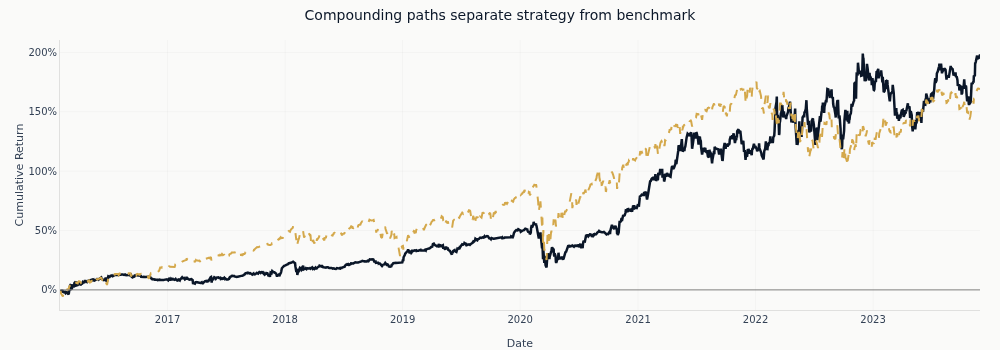

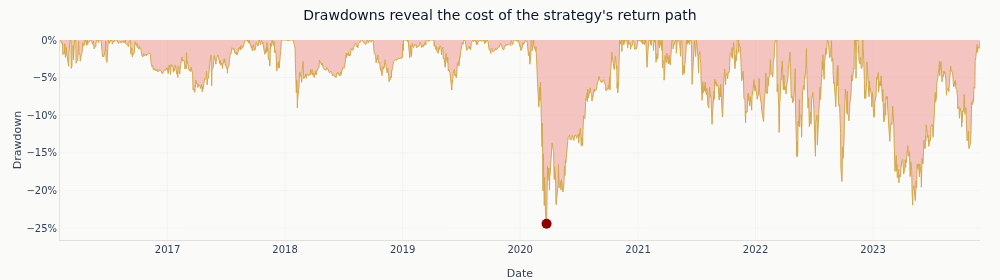

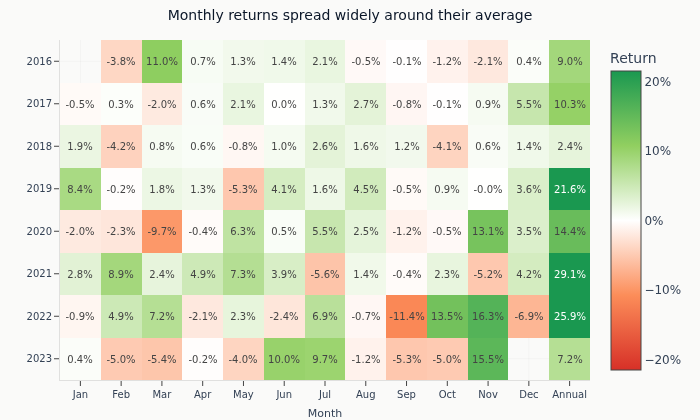

In [38]:
dashboard_titles = {
    "Cumulative Returns": "Compounding paths separate strategy from benchmark",
    "Drawdown": "Drawdowns reveal the cost of the strategy's return path",
    "Monthly Returns Heatmap": "Monthly returns spread widely around their average",
}
dashboard_alt = {
    "Cumulative Returns": (
        "Two cumulative return paths against date, the strategy and the SPY benchmark, "
        "both compounding upward and separating over the sample."
    ),
    "Drawdown": (
        "The strategy's underwater curve against date, at or below zero throughout, with "
        "the deepest fall during the early-2020 window."
    ),
    "Monthly Returns Heatmap": (
        "Heatmap of monthly return, years down the vertical axis and calendar months "
        "across, coloured red for losses and green for gains."
    ),
}
for name, title in dashboard_titles.items():
    fig = tear_sheet.figures[name]
    fig.update_layout(
        title=title,
        paper_bgcolor=COLORS["bg_light"],
        plot_bgcolor=COLORS["bg_light"],
    )
    show_plotly_with_alt(fig, dashboard_alt[name])

### Saving the dashboard as a file

`save_html` writes every figure and its metrics into one file that opens in a browser with no
Python installed. `include_plotlyjs="cdn"` keeps the file small by loading the plotting library
from the network when it opens, which is the right trade unless the file has to work offline.

In [39]:
# Export to HTML (self-contained, shareable file)
html_path = OUTPUT_DIR / "portfolio_dashboard.html"
tear_sheet.save_html(html_path, include_plotlyjs="cdn")
print(f"Dashboard saved to: {html_path.name}")

Dashboard saved to: portfolio_dashboard.html


## 14. Assembling a custom report

The dashboard above is fixed: it decides which figures appear and in what order. A report going
to someone who is not reading the notebook usually needs a different selection and a sentence
beside each figure saying what to look at. `combine_figures_to_html` takes the figures already
built here plus that narrative and writes one self-contained file.

In [40]:
# Collect figures we created earlier for a custom report
custom_figures = []
custom_sections = []

The first custom section focuses on cumulative growth against the benchmark.

In [41]:
# Add cumulative returns figure
fig_cum = go.Figure()
fig_cum.add_trace(
    go.Scatter(
        x=strategy_returns.index,
        y=(1 + strategy_returns).cumprod(),
        name="Strategy",
        line=dict(color=COLORS["blue"], width=2),
    )
)
fig_cum.add_trace(
    go.Scatter(
        x=spy_returns.index,
        y=(1 + spy_returns).cumprod(),
        name="Benchmark (SPY)",
        line=dict(color=COLORS["neutral"], width=1, dash="dash"),
    )
)
fig_cum.update_layout(
    title="Compounding paths separate strategy from benchmark",
    xaxis_title="Date",
    yaxis_title="Cumulative Return",
    height=400,
)
custom_figures.append(fig_cum)
custom_sections.append(
    {
        "title": "Strategy Performance",
        "text": f"The strategy achieved a total return of {metrics.total_return * 100:.1f}% "
        f"vs benchmark return of {((1 + spy_returns).prod() - 1) * 100:.1f}%. "
        f"Sharpe ratio: {metrics.sharpe_ratio:.2f}.",
        "figure_index": 0,
    }
)

The second section summarizes drawdown severity and recovery behavior.

In [42]:
# Add drawdown figure
fig_dd = go.Figure()
fig_dd.add_trace(
    go.Scatter(
        x=dd_series.index,
        y=dd_series * 100,
        fill="tozeroy",
        line=dict(color=COLORS["negative"], width=1),
        name="Drawdown",
    )
)
fig_dd.update_layout(
    title="Drawdowns reveal the cost of the strategy's return path",
    xaxis_title="Date",
    yaxis_title="Drawdown (%)",
    height=350,
)
custom_figures.append(fig_dd)
custom_sections.append(
    {
        "title": "Risk Analysis",
        "text": f"Maximum drawdown reached {metrics.max_drawdown * 100:.1f}%. "
        f"The strategy has a Calmar ratio of {metrics.calmar_ratio:.2f}.",
        "figure_index": 1,
    }
)

Export the assembled figures and narrative as a standalone HTML report.

In [43]:
# Generate the custom report
report_path = OUTPUT_DIR / "custom_strategy_report.html"
combine_figures_to_html(
    figures=custom_figures,
    title="Strategy Performance Report",
    sections=custom_sections,
    output_file=report_path,
    theme="default",
    include_toc=True,
)
print(f"Custom report saved to: {report_path.name}")

Custom report saved to: custom_strategy_report.html


### What this run produced

The strategy analysed is whichever allocation backtest the ETF case study currently ranks first
on validation Sharpe; its hash, allocator, cost model and execution convention are printed in
section 1, and every number in this notebook is computed from that one artifact. The summary table in
section 11 is the full set. Three things in it are worth reading together rather than
separately: the annualized return against the annual volatility it was earned at, the maximum
drawdown against the Calmar ratio that divides the return by it, and the alpha against the beta
and tracking error that say how much market exposure and how much active deviation produced it.

The rolling panels in section 4 are what the aggregate figures hide. Where the 252-session
Sharpe and the 21-session Sharpe disagree for an extended stretch, the aggregate is an average
over two different regimes rather than a description of one process.

## Key Takeaways

1. **One ratio cannot describe a return path.** Sharpe divides return by total volatility,
   so it registers neither how far the path fell nor how long it stayed down, and it treats
   an upside surprise as a cost. Report it alongside the maximum drawdown and the Sortino
   ratio, which are blind to different things.
2. **Rolling metrics expose regime dependence.** Aggregate Sharpe can be positive
   while rolling windows show extended negative periods - a critical warning for
   investors with finite horizons.
3. **Benchmark comparison separates alpha from beta.** Alpha, beta, tracking error,
   and information ratio must be read together. Up/down capture reveals asymmetric
   exposure that aggregate alpha misses.
4. **Stress-period analysis tests robustness.** The maximum drawdown and event panels
   turn an aggregate performance score into the timing and recovery questions that
   matter to investors.

### Known limitations

- **One strategy, one benchmark, one sample.** Every number here describes a single backtest
  over a single history. None of them carries a confidence interval, and the Sharpe ratio in
  particular is estimated with a standard error close to 1/sqrt(years) - so two strategies
  differing by a few tenths over a few years have not been separated by this evidence.
- **The strategy was chosen by validation Sharpe.** Ranking a set of candidates and then
  reporting the statistics of the one that ranked first overstates them, because the ranking itself used the same
  kind of noise the statistic measures. This notebook is a diagnostic of a chosen artifact, not
  an unbiased estimate of what that artifact would earn next.
- **Stress periods are named by hand.** The five windows in section 9 were chosen because they
  are known episodes, which means the selection is retrospective. They show how the strategy
  behaved in them; they do not establish how it behaves in stress generally.
- **VaR and CVaR are empirical quantiles.** Both are read off the sample's own distribution, so
  the 99% figures rest on a few dozen observations and neither extrapolates past the worst day
  in the history.
- **The risk-free rate is zero.** Ratios that subtract it are therefore excess-over-nothing
  rather than excess-over-cash, which flatters them over any period when cash paid a return.

**Next**: These metrics are used throughout Ch17-19 to evaluate allocation methods,
transaction cost impact, and risk controls.

**Book**: Section 17.3 discusses the full evaluation framework.